## 1.1 Load dataset and libraries

In [1]:
DATA_PATH = "../IberFire.nc" # set your path to IberFire dataset here

In [2]:
import matplotlib.pyplot as plt
import xarray as xr
from pathlib import Path
import numpy as np
import pandas as pd

In [3]:
ds = xr.open_dataset(DATA_PATH)
ds

<xarray.Dataset> Size: 731GB
Dimensions:                                        (y: 920, x: 1188, time: 6241)
Coordinates:
  * y                                              (y) float64 7kB 2.492e+06 ...
  * x                                              (x) float64 10kB 2.675e+06...
  * time                                           (time) datetime64[ns] 50kB ...
Data variables: (12/261)
    x_index                                        (y, x) uint16 2MB ...
    y_index                                        (y, x) uint16 2MB ...
    is_spain                                       (y, x) uint16 2MB ...
    is_fire                                        (time, y, x) uint8 7GB ...
    is_near_fire                                   (time, y, x) uint8 7GB ...
    x_coordinate                                   (y, x) float32 4MB ...
    ...                                             ...
    LST                                            (time, y, x) float32 27GB ...
    SWI_001                                        (time, y, x) float32 27GB ...
    SWI_005                                        (time, y, x) float32 27GB ...
    SWI_010                                        (time, y, x) float32 27GB ...
    SWI_020                                        (time, y, x) float32 27GB ...
    FWI                                            (time, y, x) float32 27GB ...
Attributes: (12/17)
    title:                IberFire
    description:          Datacube centered in Spain with 1km x 1km spatial r...
    dimensions:           (y: 920, x: 1188, time: 6241)
    spatial_resolution:   1km x 1km
    temporal_resolution:  Daily
    start_date:           2007-12-01
    ...                   ...
    geospatial_x_max:     3861734.3466
    geospatial_y_min:     1573195.9911000002
    geospatial_y_max:     2492195.9911
    author:               Julen Ercibengoa Calvo
    author_contact:       julen.ercibengoa@gmail.com, julen.ercibengoa@teknik...
    creation_date:        2025-04-04

1199 km wide, 920 km high -> 1x1 cells -> 1,092,960 cells

## 1.2 Basic EDA

Fires in Spain on 2022-06-15

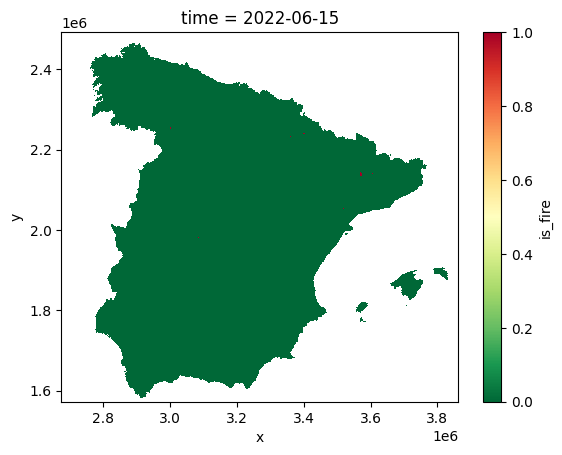

In [ ]:

fire = ds["is_fire"].sel(time="2022-06-15")
fire.where(ds["is_spain"]==1).plot(cmap="RdYlGn_r")
plt.show()

Fires in Catalonia vs Spain

In [ ]:
# Compute overall fire-positive rate for Catalonia vs Spain (memory-safe with chunking).

# Re-open dataset with chunking and only required variables to keep memory usage low.

ds_small = xr.open_dataset(
    DATA_PATH,
    chunks="auto",
    drop_variables=[v for v in ds.data_vars if v not in ["is_fire", "is_spain", "AutonomousCommunities"]],
)

# Define masks (broadcasted over time automatically).
cat_mask = ds_small["AutonomousCommunities"] == 9
spain_mask = ds_small["is_spain"] == 1

# Catalonia: numerator and denominator across all timesteps and cells.
cat_fires = ds_small["is_fire"].where(cat_mask).sum().compute().item()
cat_total = ds_small["is_fire"].where(cat_mask).count().compute().item()

# Spain: numerator and denominator across all timesteps and cells.
spain_fires = ds_small["is_fire"].where(spain_mask).sum().compute().item()
spain_total = ds_small["is_fire"].where(spain_mask).count().compute().item()

cat_rate = (cat_fires / cat_total)
spain_rate = (spain_fires / spain_total)

print(f"total fires in catalonia: {cat_fires}")
print(f"total events in catalonia: {cat_total}")
print(f"Catalonia fire-positive rate: {cat_rate:.6%}")

print(f"Total fires in spain: {spain_fires}")
print(f"Total events in spain: {spain_total}")
print(f"Spain fire-positive rate: {spain_rate:.6%}")

total fires in catalonia: 1626.0
total cells in catalonia: 200348582
Catalonia fire-positive rate: 0.000812%
Total fires in spain: 73460.0
Total cells in spain: 3111325730
Spain fire-positive rate: 0.002361%


Visualize fires per year and month, which later we will compare with the sampled dataset to validate it.

In [ ]:
# Only load is_fire, chunked for Dask
ds_small = xr.open_dataset(
    DATA_PATH,
    chunks={"time": 31, "y": 128, "x": 128},
    drop_variables=[v for v in xr.open_dataset(DATA_PATH).data_vars if v != "is_fire"],
)

# Sum over space first (memory-safe), then aggregate by year/month
fires_per_time = ds_small["is_fire"].sum(dim=("y", "x"))
fires_per_year = fires_per_time.groupby("time.year").sum().compute()
fires_per_month = fires_per_time.groupby("time.month").sum().compute()

/tmp/ipykernel_3385/1782497903.py:7: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 31. This could degrade performance. Instead, consider rechunking after loading.
  ds_small = xr.open_dataset(
/tmp/ipykernel_3385/1782497903.py:7: UserWarning: The specified chunks separate the stored chunks along dimension "y" starting at index 128. This could degrade performance. Instead, consider rechunking after loading.
  ds_small = xr.open_dataset(
/tmp/ipykernel_3385/1782497903.py:7: UserWarning: The specified chunks separate the stored chunks along dimension "x" starting at index 128. This could degrade performance. Instead, consider rechunking after loading.
  ds_small = xr.open_dataset(


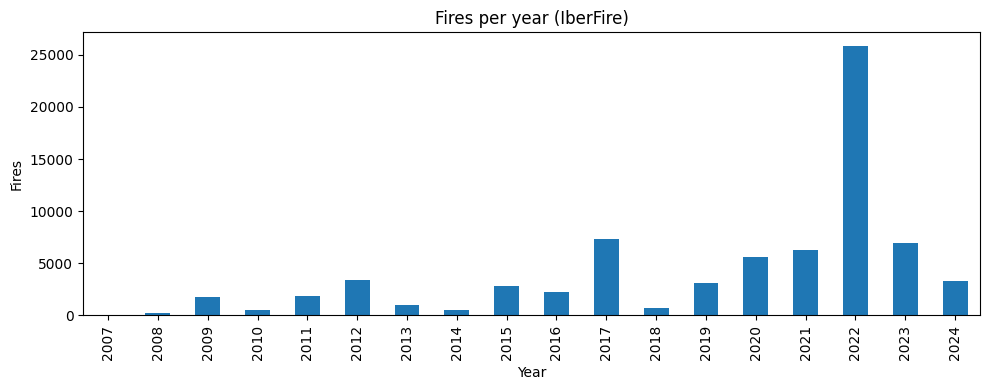

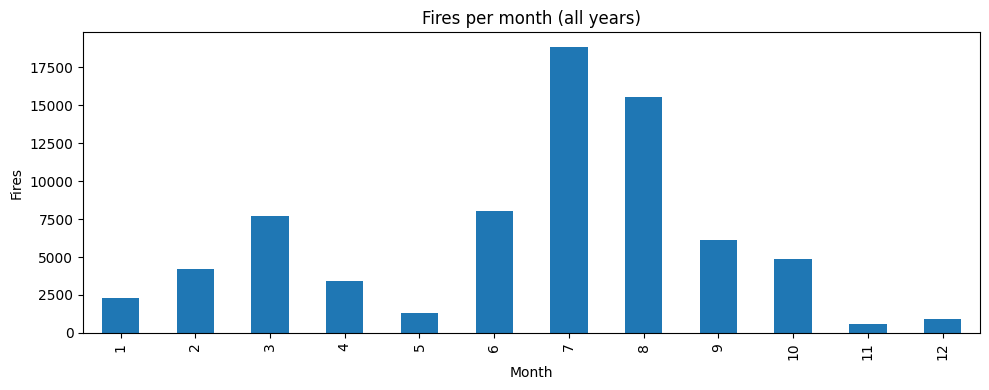

In [14]:
# Convert to pandas Series (index = year / month)
fires_per_year_pd = fires_per_year.to_pandas()
fires_per_month_pd = fires_per_month.to_pandas()

# Plot with pandas
fires_per_year_pd.plot(kind="bar", figsize=(10, 4), title="Fires per year (IberFire)")
plt.xlabel("Year")
plt.ylabel("Fires")
plt.tight_layout()
plt.show()

fires_per_month_pd.plot(kind="bar", figsize=(10, 4), title="Fires per month (all years)")
plt.xlabel("Month")
plt.ylabel("Fires")
plt.tight_layout()
plt.show()